In [1]:
#Amo evaluation
#FM 28.11.2025
import sys
sys.path.extend(['src', '../src']) 
# Import all ML orchestration functions
from amo.ml_orchestration import (
    ml_exp_with_timing,  # Main experiment function with timing preservation
    extract_timing_structure,
    save_midi_with_exact_timing_structure,
    KerasClassifierWrapper,
    build_lstm_classifier,
    build_transformer_classifier,
    clf_predict,
    defineXy,           # Data preparation function
    split_and_encode    # Train/test split with encoding
)
# Import MIDI processing functions  
from amo.midi2df2midi import midi_to_dataframe, save_midi_from_df
from amo.mappings import fill_quaterna_columns, learn_quaterna_mapping
# Import amo funtion
from amo.ml_orchestration import amo_with_doublings_multiclass

import pandas as pd
import numpy as np
from collections import defaultdict


from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

import matplotlib.pyplot as plt



In [2]:
# amo_with_doublings
# Args:
  #      filein (str): Path to the source MIDI file to learn orchestration style from.
  #      fileout (str): Path to the target MIDI file to be orchestrated.
  #      ytarget (str, optional): The target variable for the model ('track-channel' or 'program').
  #                               Defaults to "track-channel".
  #      model (str, optional): The name of the machine learning model to use for orchestration.
  #     ("XGBoost","RandomForest", "DecisionTree", "NearestNeighbors", "MLP3", "NaiveBayes", "MLP1", "AdaBoost", "LSTMClassifier", "TransformerClassifier")
  #                             Defaults to "XGBoost".

In [3]:
def transpose(note, inverse=False, n_semitones=12):
    # Example: transpose pitch
    if inverse:
        n_semitones = - n_semitones
    new_note = note.copy()
    new_note['pitch'] = note['pitch'] + n_semitones
    return [ new_note ]

In [4]:
transformations = [
    (transpose, {'n_semitones': 12}),
    (transpose, {'n_semitones': 24}),
    (transpose, {'n_semitones': 46}),
    (transpose, {'n_semitones': -12}),
    (transpose, {'n_semitones': -24}),
    (transpose, {'n_semitones': -46}),
    #(split_duration, {'smallest_unit': 0.25}),
]

In [5]:
"""
Prompt by GV
create a python function to read the path of .mid files which contain the string "orch". Files are inside folders like "folder_name1/la_mer_1_orch.mid", "folder_name2/symphony_9_2_orch.mid", etc.
"""
import os

def find_orch_mid_files(root_dir='.'):
    result = []
    for dirpath, _, filenames in os.walk(root_dir):
        for name in filenames:
            if name.lower().endswith('.mid') and 'orch' in name.lower():
                result.append(os.path.join(dirpath, name))
    return result

In [6]:
#get the parent directory
cwd = os.getcwd()
parent = os.path.normpath(os.path.join(cwd, '..', '..'))
path_AMO = parent + '/AutomaticMusicOrchestration'
model_path = path_AMO + '/'
#print(parent)#.../test
#print(path_AMO)

In [7]:
#root_dir='LOP_database_06_09_17/hand_picked_Spotify'
root_dir=parent+'/music/LOP_database_06_09_17/hand_picked_Spotify'
filenames = find_orch_mid_files(root_dir)
len(filenames)

55

In [12]:
model_names = [
        "DecisionTree",
        "DummyUnif",      
    ]


model_names_short = [
    'DT',
    'DU',
    ]

classifiers = [
    DecisionTreeClassifier(),
    DummyClassifier(strategy='uniform'),
]

In [8]:
'''
model_names = [
        "XGBoost",
        "XGBoost5",
        "XGBoost10",
        "XGBoost20",
        "XGBoost50",
        "RandomForest",
        "RandomForest10",
        "RandomForest13",
        "RandomForest16",
        "RandomForest20",
        "DecisionTree",
        #"LSTMClassifier",      # Added
        "NearestNeighbors",
        #"MLP3",   
        #"TransformerClassifier", # Added
        "NaiveBayes",
        #"MLP1",
        "AdaBoost",
        "Dummy0",
        "Dummy1",
        "DummyUnif",      
    ]


model_names_short = [
    'XGB',
    'XGB5',
    'XGB10',
    'XGB20',
    'XGB50',
    'RF',
    'RF10',
    'RF13',
    'RF16',
    'RF20',
    'DT',
    #'LSTM*',
    'NN',
    #'MLP3*',
    #'TF',
    'NB',
    #'MLP1',
    'AB',
    'D0',
    'D1',
    'DU',
    ]

classifiers = [
    XGBClassifier(),
    XGBClassifier(n_estimators = 5),
    XGBClassifier(n_estimators = 10),
    XGBClassifier(n_estimators = 20),
    XGBClassifier(n_estimators = 50),
    RandomForestClassifier(),
    RandomForestClassifier(max_depth=10),
    RandomForestClassifier(max_depth=13),
    RandomForestClassifier(max_depth=16),
    RandomForestClassifier(max_depth=20),
    DecisionTreeClassifier(),
    #KerasClassifierWrapper(build_lstm_classifier),      # Added LSTM
    KNeighborsClassifier(1),
    #MLPClassifier(hidden_layer_sizes=(128,128,128)),
    #KerasClassifierWrapper(build_transformer_classifier),# Added Transformer
    GaussianNB(),
    #MLPClassifier(),
    AdaBoostClassifier(),
    DummyClassifier(strategy='constant', constant=0),
    DummyClassifier(strategy='constant', constant=1),
    DummyClassifier(strategy='uniform'),
]
'''

In [13]:
# Reduce for testing purposes, remove this cell for the actual experiment
N_files = len(filenames)
N_models = len(classifiers)

filenames = filenames[:N_files]

model_names = model_names[:N_models]
classifiers = classifiers[:N_models]
model_names_short = model_names_short[:N_models]

In [14]:
# Initialize metrics collectors
s = (len(filenames),len(model_names))
ml_metrics = dict()
base_metrics_names = ["time",
                      "accuracy (train)",
                      "accuracy (test)",
                      "precision (train)",
                      "precision (test)",
                      "recall (train)",
                      "recall (test)",
                      "f1 (train)",
                      "f1 (test)",
                      ] #, "n_events", "n_classes"]
ml_metrics_names = base_metrics_names.copy()

for func, kwargs in transformations:
    trans_target_name = f"{func.__name__}_{kwargs}"
    for bmn in base_metrics_names:
        ml_metrics_names.append(f"{bmn} ({trans_target_name})")

for mn in ml_metrics_names:
    ml_metrics[mn] = np.zeros(s)

In [15]:
# Multiclass, with transformations
error_collection = []
for i, filein in enumerate(filenames):    
    for u, (model_name, clf) in enumerate(zip(model_names, classifiers)):
        try: 
            metrics = amo_with_doublings_multiclass(filein,fileout=None,model=model_name, tol=0.2, transformations=transformations, model_path=model_path)
            print(metrics)
            for mn in ml_metrics_names:
                # ml_metrics["accuracy"][i,u] = metrics["accuracy"]
                ml_metrics[mn][i,u] = metrics[mn]
        except Exception as e:
            print("Error")
            error_collection.append(f"Error with {filein} and model {model_name}: {e}")

print("\n????????? ERRORS ??????????")
for error in error_collection:
    print(error)


========= PREPROCESSING =========
[CACHE] Loading preprocessing results from memory...

========= TRAINING (with multi-class option) =========

Instrument classification
--------- DecisionTree (Multi-Output) ---------
Train Time (sec): 1.1877
Score on Test (20%): 0.6714
Precision (micro): 0.8003
Recall (micro): 0.7824
F1-Score (micro): 0.7913
Confusion Matrices for Individual Classes:
--- Class: 10_9 A10-STANDARD 1   ---
[[5217    2]
 [   7  151]]
--- Class: 11_10 A11-FrenchHorns  ---
[[5217   36]
 [  31   93]]
--- Class: 12_11 A12-Trumpet      ---
[[5275   15]
 [  20   67]]
--- Class: 13_12 A13-Trumpet      ---
[[5129   38]
 [  49  161]]
--- Class: 14_13 A14-Trombone 2   ---
[[5370    0]
 [   0    7]]
--- Class: 15_14 A15-Trombone 2   ---
[[5156   23]
 [  53  145]]
--- Class: 16_15 A16-Trombone 2   ---
[[5360    1]
 [   7    9]]
--- Class: 17_0 B1-Tuba         ---
[[5348    8]
 [   9   12]]
--- Class: 18_1 B2-Timpani      ---
[[5138   10]
 [  13  216]]
--- Class: 19_2 B3-Piano 1     

In [16]:
def return_m_std(ml_metrics, metric_name):
    print(metric_name)
    mean = np.nanmean(ml_metrics, axis=0)
    std = np.nanstd(ml_metrics, axis=0)
    print(mean)
    print(std)
    return mean, std

In [17]:
def rank_pieces_by_metric(pieces, ml_metrics, model_index=0, descending=True):
    ml_metrics = np.array(ml_metrics, dtype=float)
    metric_column = ml_metrics[:, model_index]
    paired = list(zip(pieces, metric_column))
    ranked = sorted(paired, key=lambda x: x[1], reverse=descending)

    for piece, metric in ranked:
        piece = os.path.basename(piece)
        print(f"{metric:.2f} \t{piece}")

In [18]:
metrics_mean = dict()
metrics_std = dict()
for mn in ml_metrics_names:
    metrics_mean[mn], metrics_std[mn] = return_m_std(ml_metrics[mn], mn)

time
[0.17319541 0.02629919]
[0.19094372 0.02187217]
accuracy (train)
[1.         0.00144247]
[0.         0.00776064]
accuracy (test)
[0.72562115 0.00232173]
[0.08935285 0.00936169]
precision (train)
[1.         0.07672335]
[0.        0.0486234]
precision (test)
[0.79755592 0.07457308]
[0.0673168  0.04260042]
recall (train)
[1.         0.50181196]
[0.         0.01163472]
recall (test)
[0.79776528 0.49528811]
[0.06917479 0.02801399]
f1 (train)
[1.         0.12810531]
[0.         0.06321193]
f1 (test)
[0.79761209 0.12482331]
[0.06795774 0.05486683]
time (transpose_{'n_semitones': 12})
[0.01207162 0.00316454]
[0.00969138 0.0013159 ]
accuracy (train) (transpose_{'n_semitones': 12})
[1.         0.29204612]
[0.         0.09928389]
accuracy (test) (transpose_{'n_semitones': 12})
[0.93871438 0.295298  ]
[0.04422412 0.1042103 ]
precision (train) (transpose_{'n_semitones': 12})
[1.         0.76765184]
[0.         0.14753751]
precision (test) (transpose_{'n_semitones': 12})
[0.9405636  0.77344478

In [19]:
for model_index, model_name in enumerate(model_names):
    for mn in ml_metrics_names:
        print(model_name)
        print(mn)
        rank_pieces_by_metric(filenames, ml_metrics[mn], model_index=model_index, descending=True)
        print("\n")

DecisionTree
time
1.19 	firebird_suite_orch.mid
0.47 	swan_lake_13_orch.mid
0.47 	swan_lake_28-29_orch.mid
0.42 	la_mer_3_orch.mid
0.39 	swan_lake_19_orch.mid
0.38 	1631petrushk_orch.mid
0.36 	symphony_9_4_orch.mid
0.34 	Tchaik6-3_orch.mid
0.33 	tch_sy6c_orch.mid
0.32 	swan_lake_05_orch.mid
0.31 	bbdanube_orch.mid
0.30 	swan_lake_04_orch.mid
0.30 	tch_sy6a_orch.mid
0.29 	swan_lake_01_orch.mid
0.27 	swan_lake_02_orch.mid
0.24 	nocturnes_2_orch.mid
0.23 	la_mer_1_orch.mid
0.21 	swan_lake_23_orch.mid
0.19 	swan_lake_24_orch.mid
0.19 	nocturnes_3_orch.mid
0.17 	m02101_11_orch.mid
0.15 	swan_lake_17_orch.mid
0.13 	swan_lake_15_orch.mid
0.12 	mozart-symphony40-1_orch.mid
0.12 	swan_lake_16_orch.mid
0.11 	tch_sy6b_orch.mid
0.11 	swan_lake_21_orch.mid
0.10 	swan_lake_11_orch.mid
0.09 	Dvorak-Symphony9-2-from-the-New-World_orch.mid
0.09 	swan_lake_03_orch.mid
0.09 	swan_lake_22_orch.mid
0.08 	swan_lake_20_orch.mid
0.08 	swan_lake_10_orch.mid
0.08 	swan_lake_14_orch.mid
0.08 	swan_lake_09_orch.m

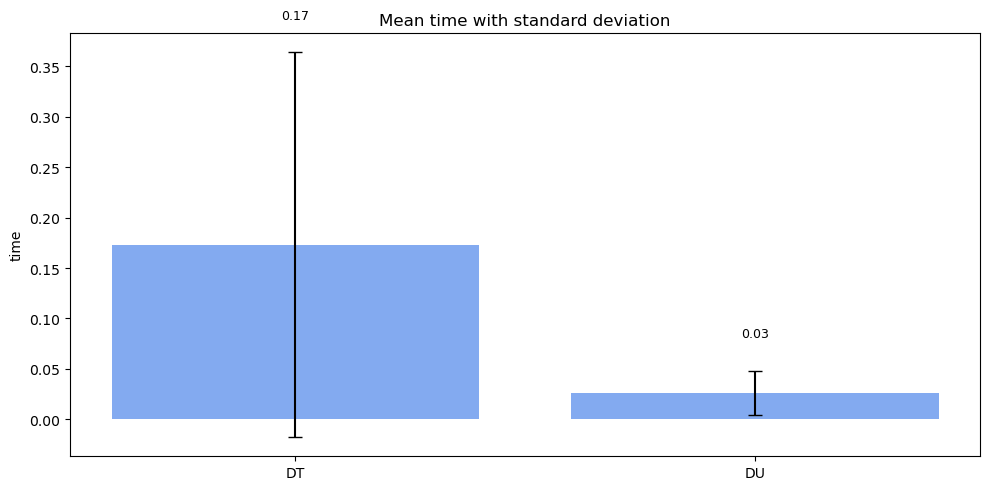

/var/folders/2q/7rpzlxd56_q9lhc9ts3wpl200000gp/T/ipykernel_85506/2124086889.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


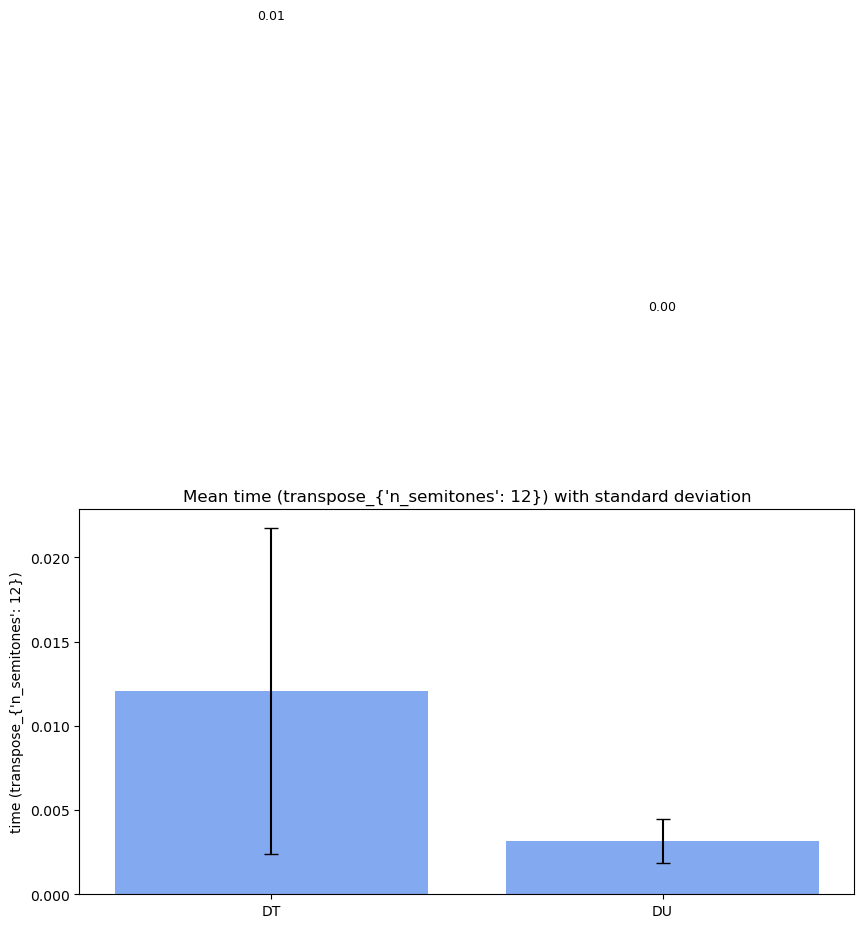

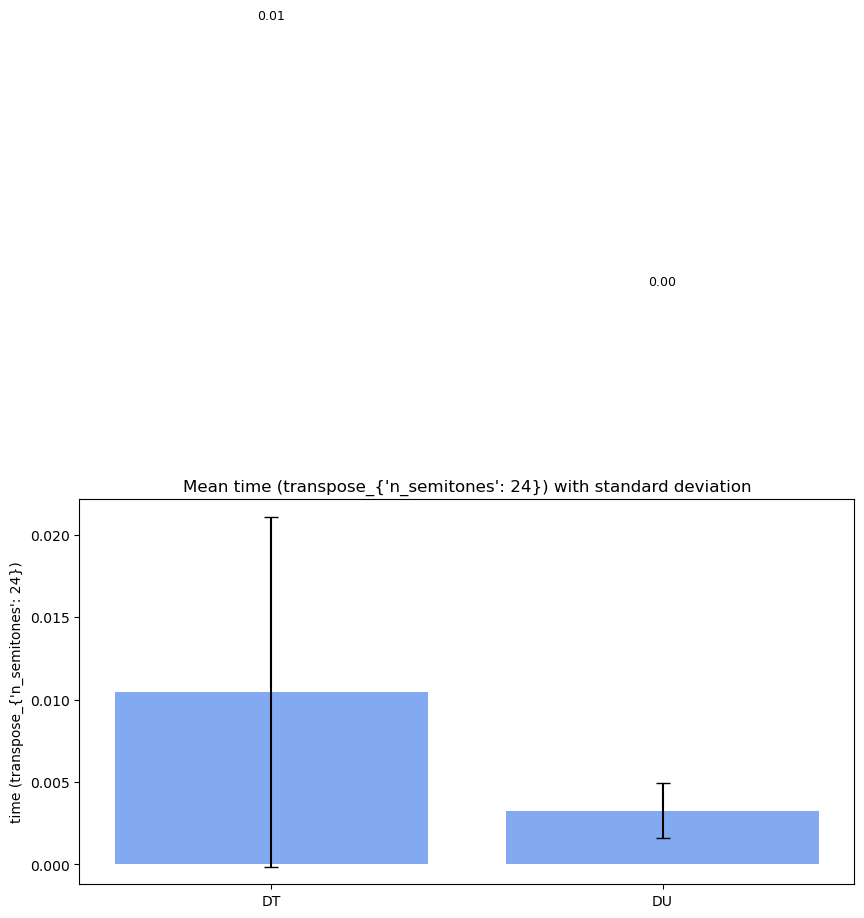

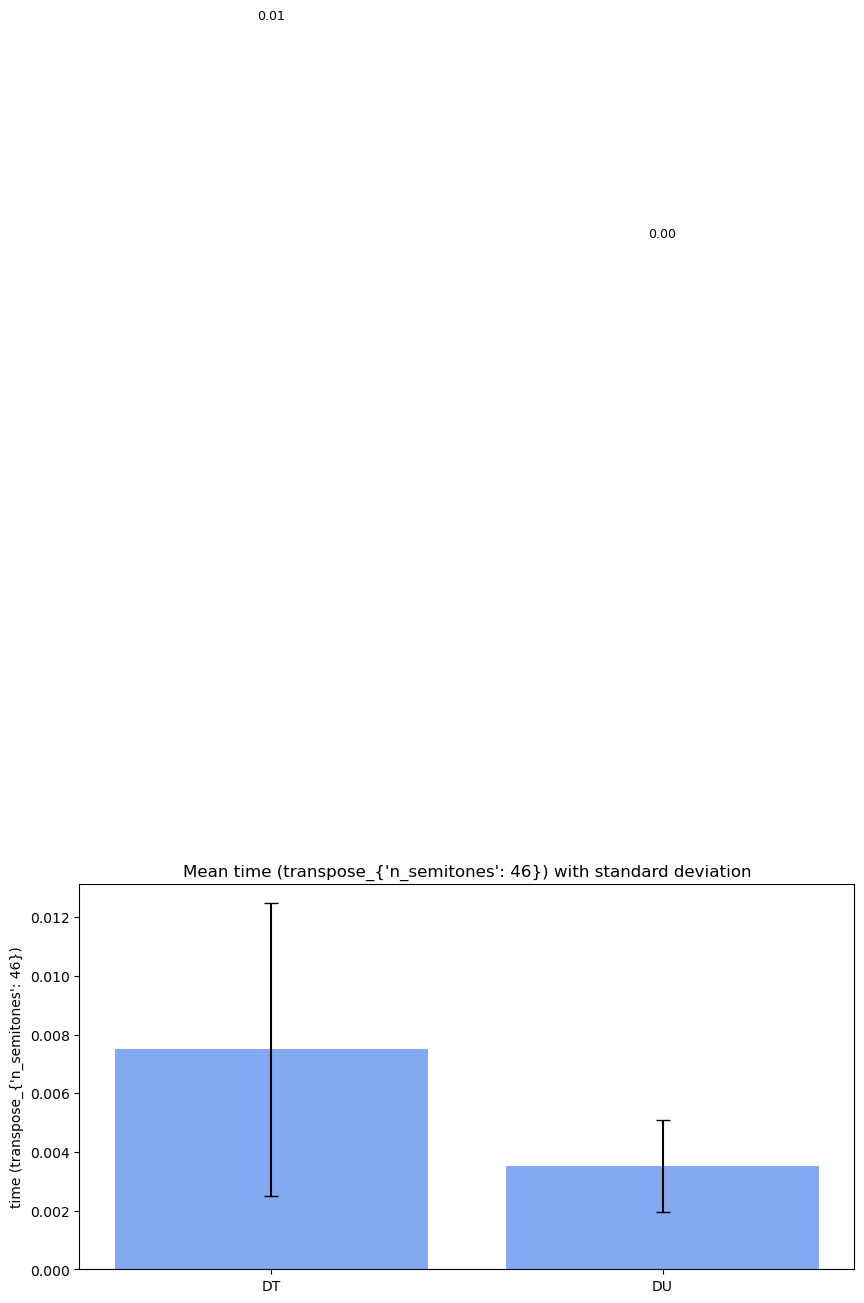

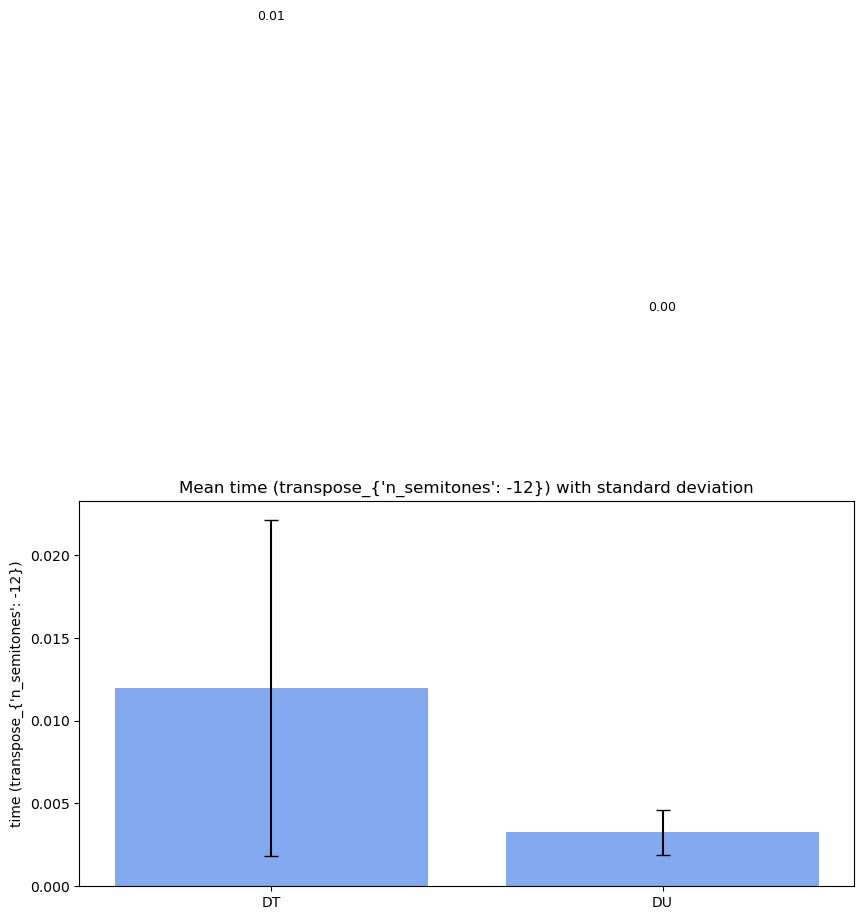

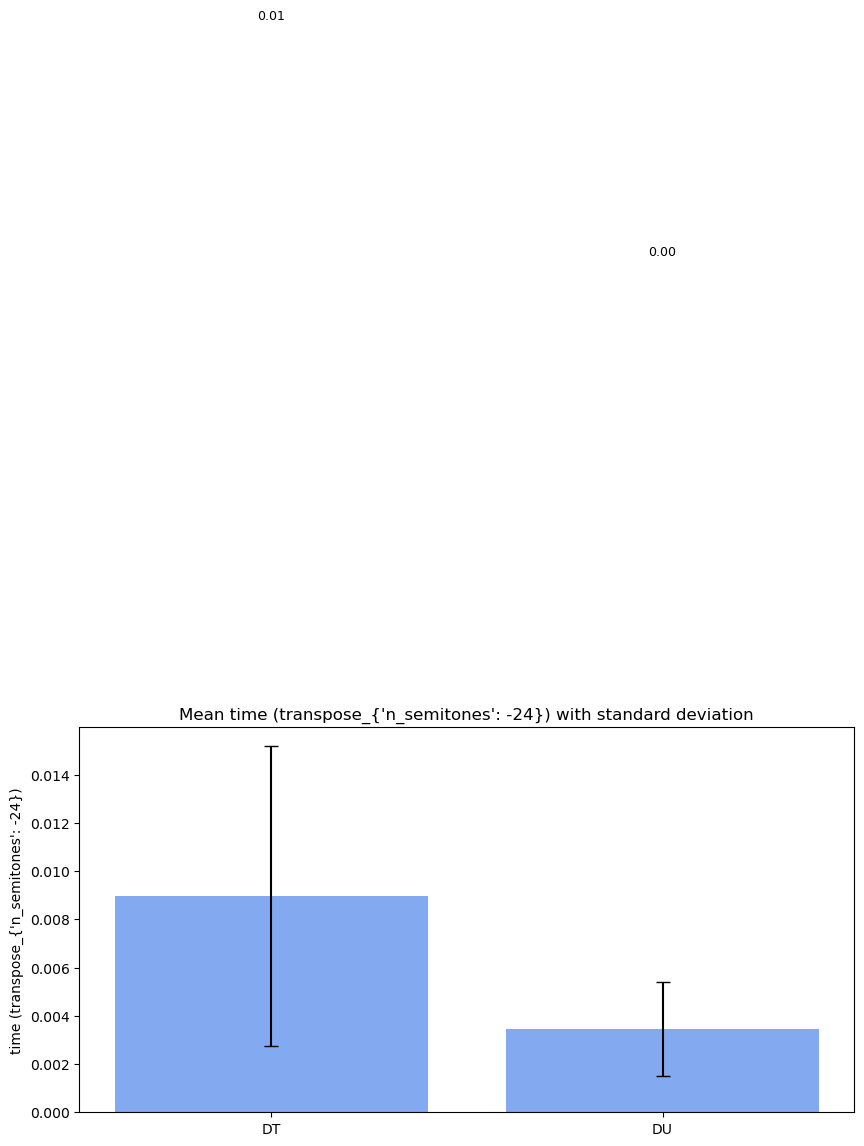

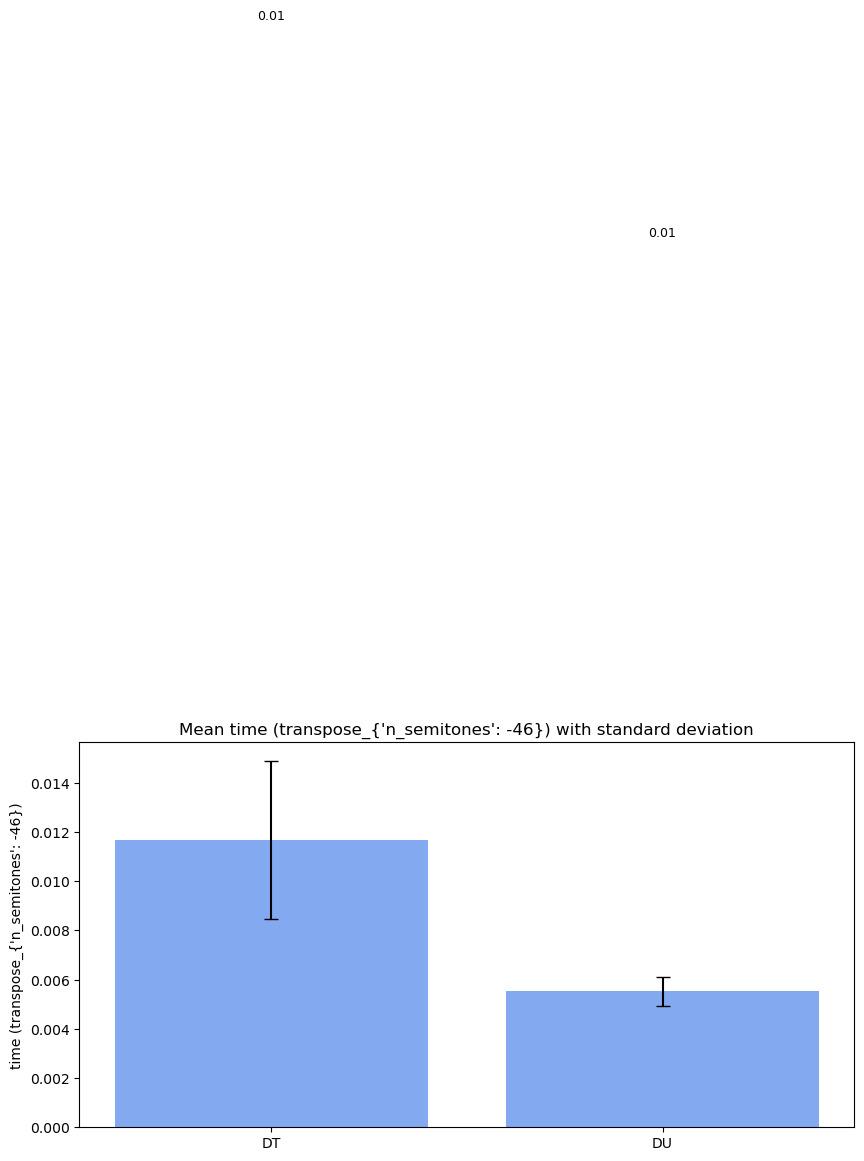

In [20]:
for mn in ml_metrics_names:
    if "time" in mn:
        # Plot
        plt.figure(figsize=(10, 5))
        barlist = plt.bar(model_names_short, metrics_mean[mn], yerr=metrics_std[mn], capsize=5, color='cornflowerblue', alpha=0.8)

        plt.ylabel(mn)
        plt.title(f'Mean {mn} with standard deviation')
        if not "time" in mn:
            plt.ylim(0, 1.1)

        # Optional: Add mean values above bars
        for i, (mean, std) in enumerate(zip(metrics_mean[mn], metrics_std[mn])):
            plt.text(i, mean + std + 0.03, f"{mean:.2f}", ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.show()

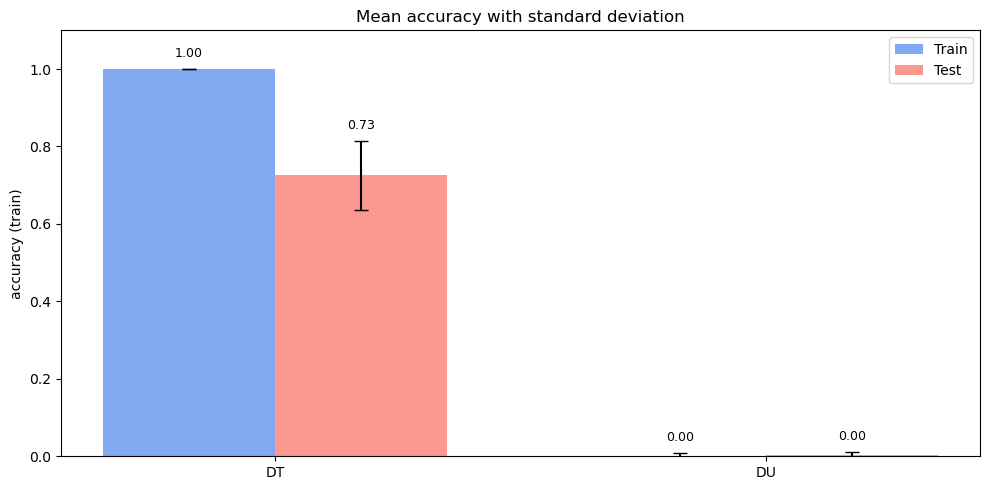

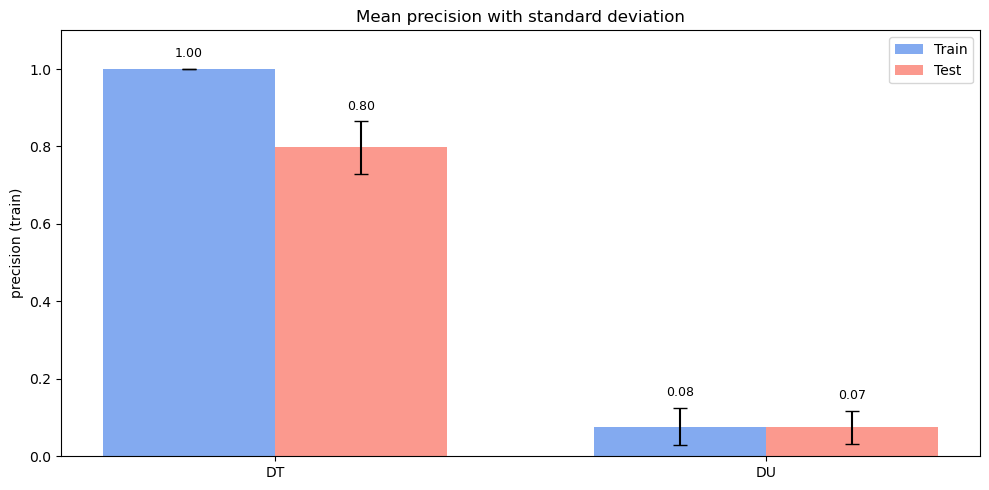

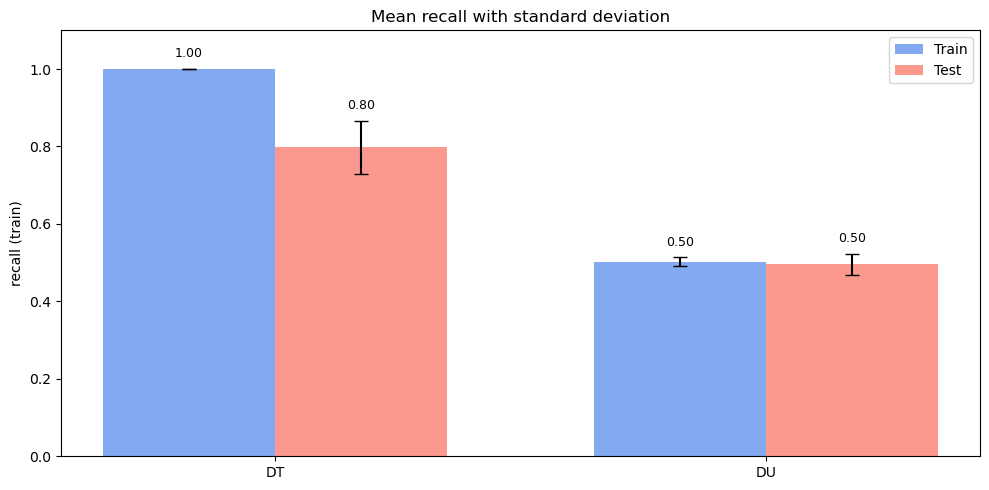

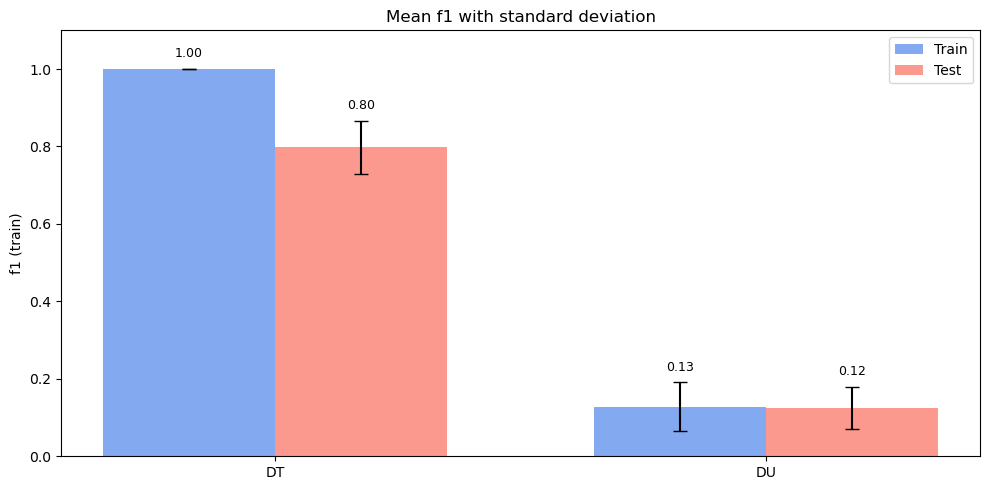

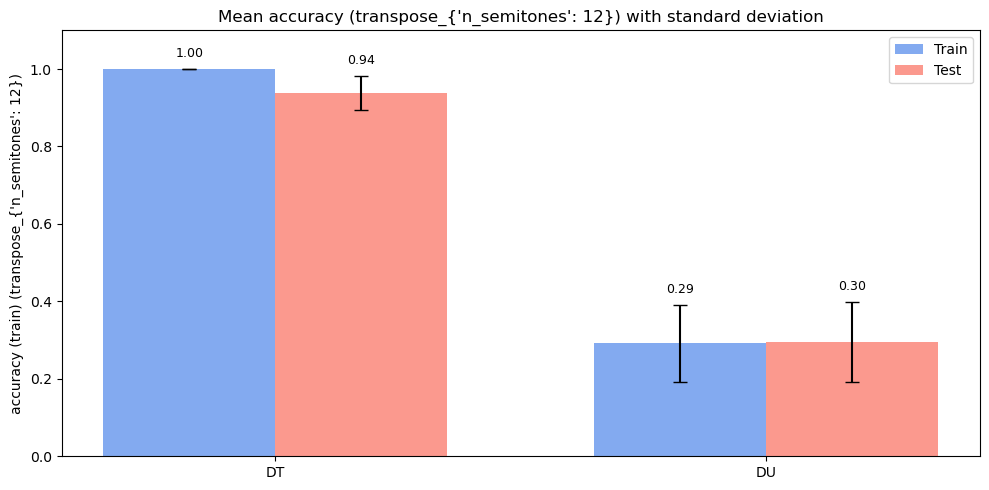

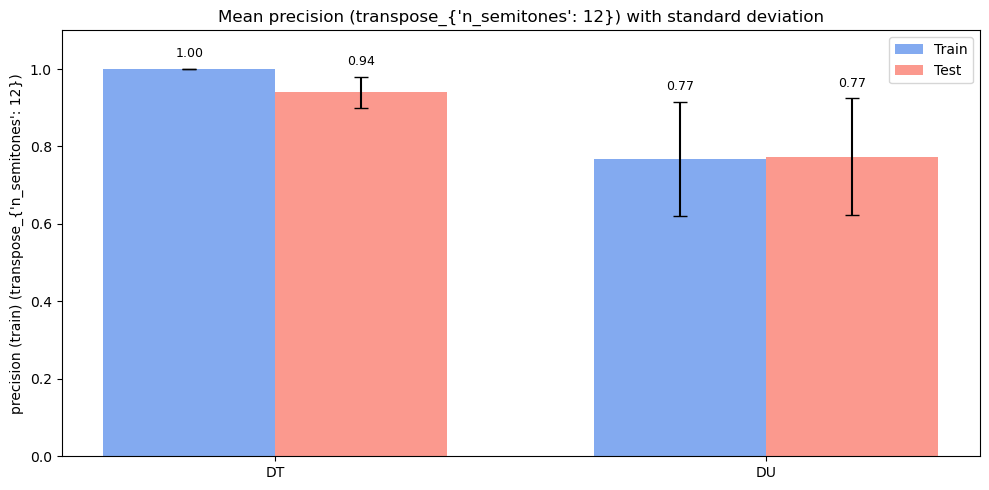

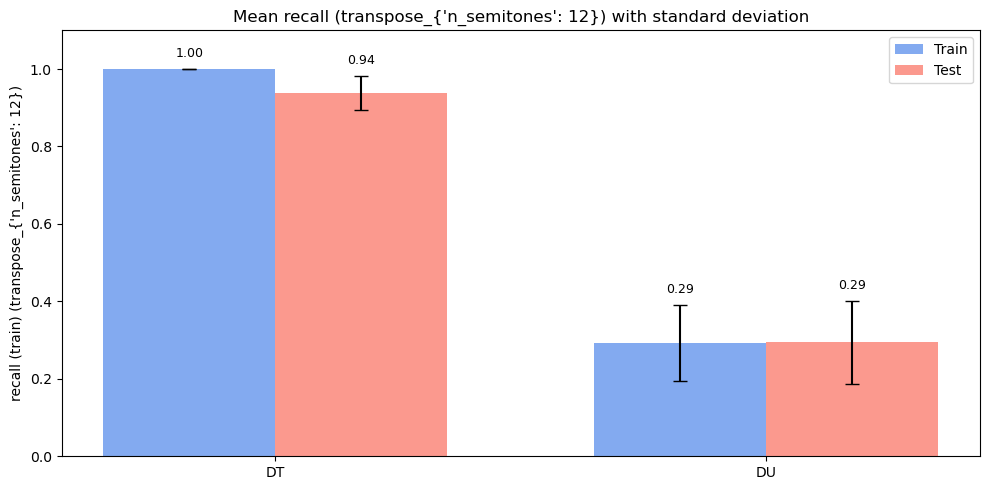

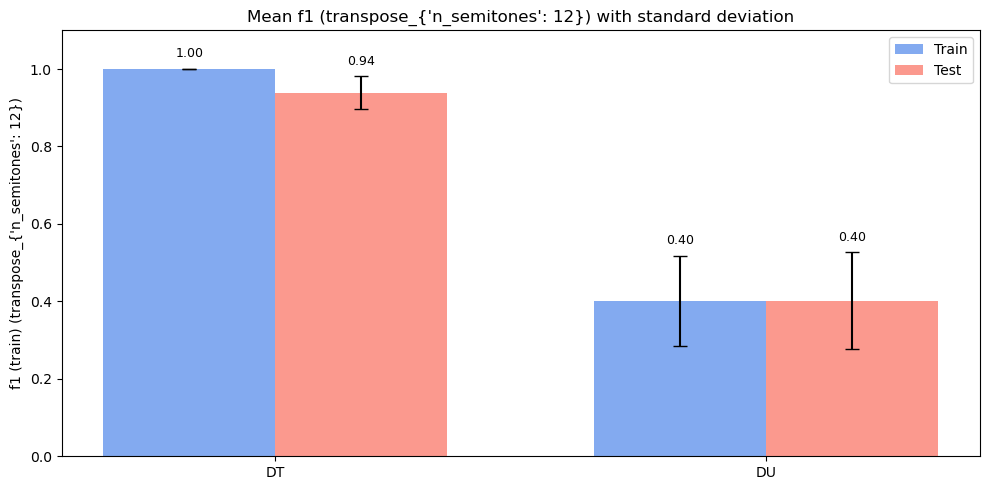

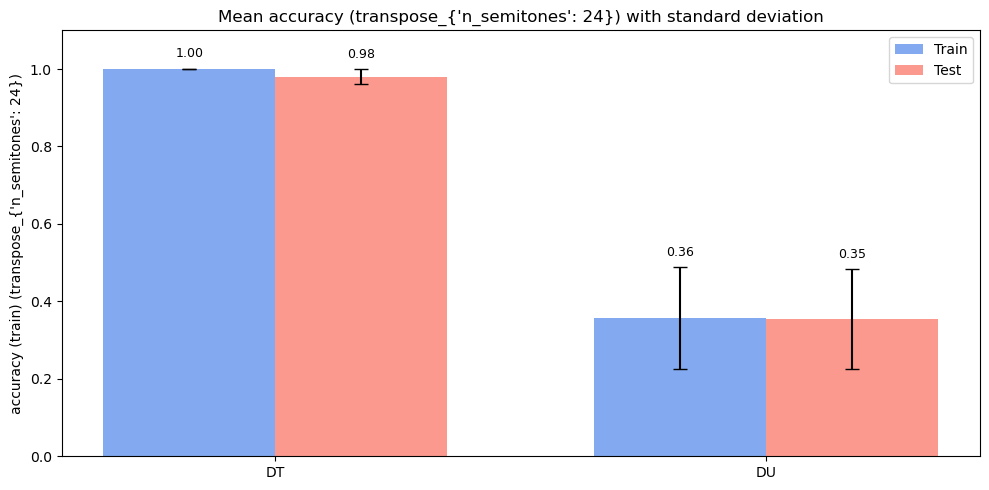

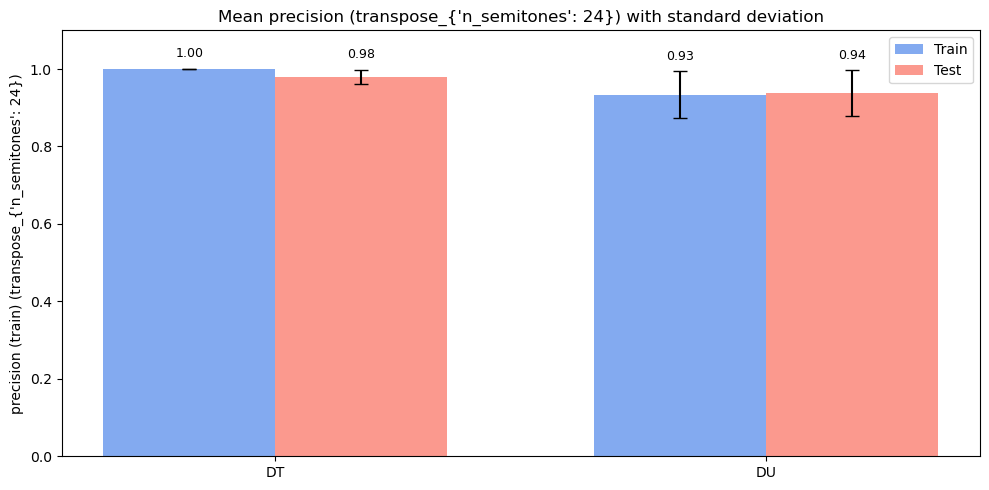

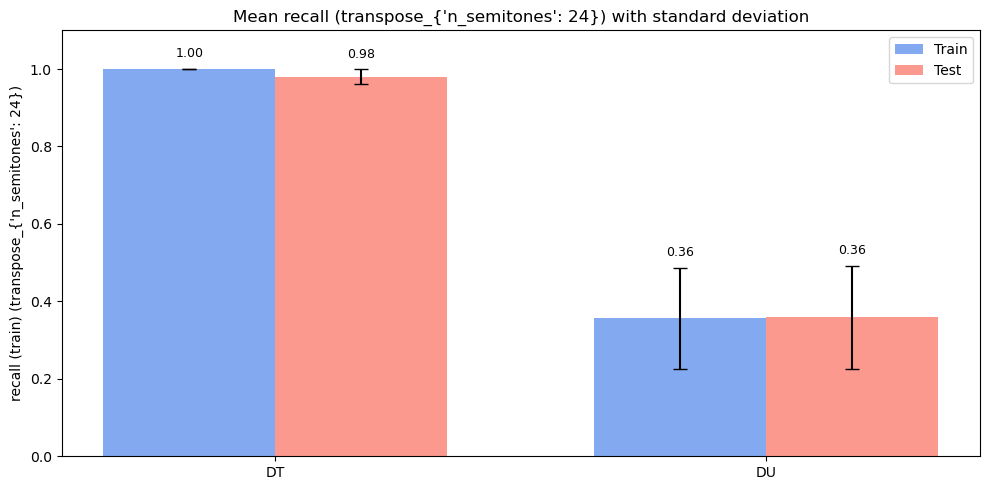

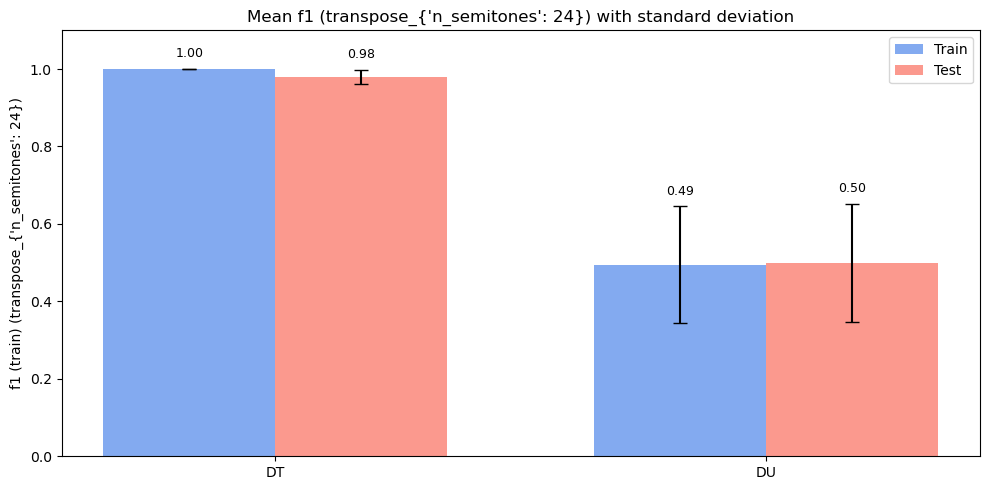

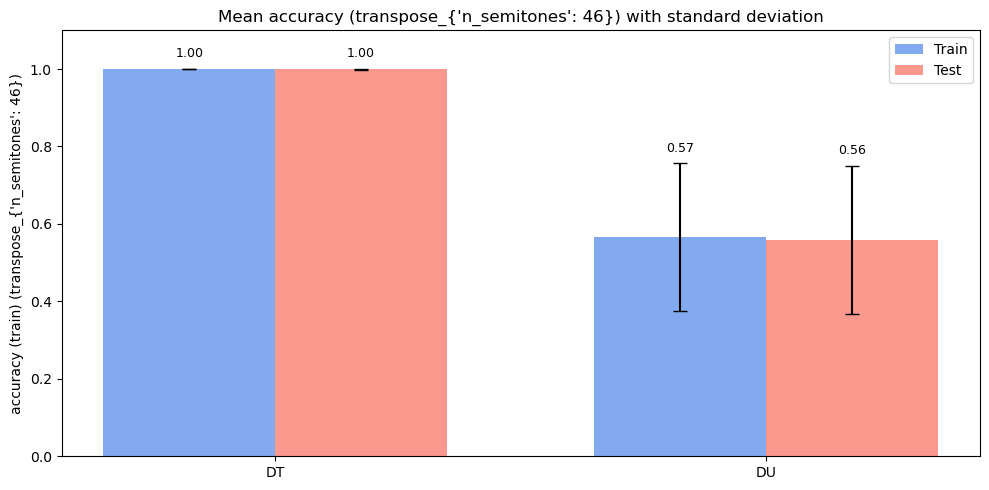

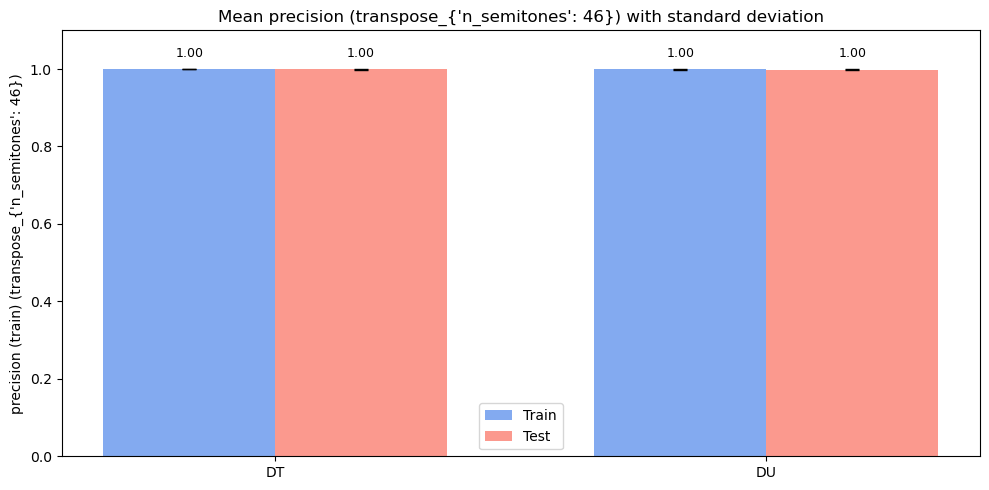

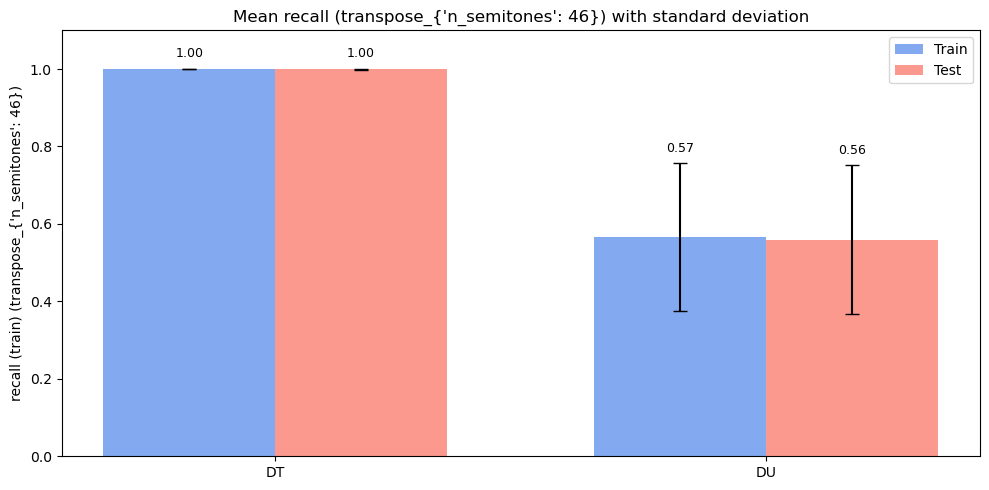

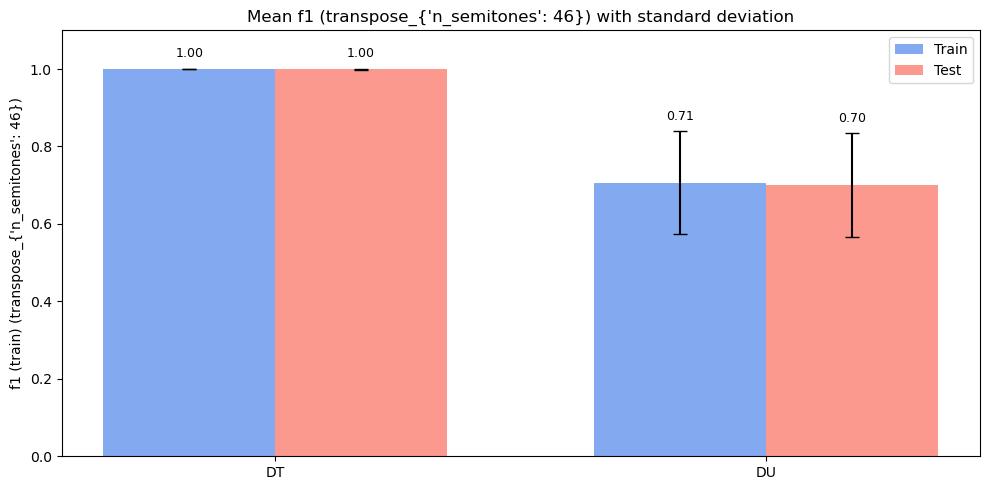

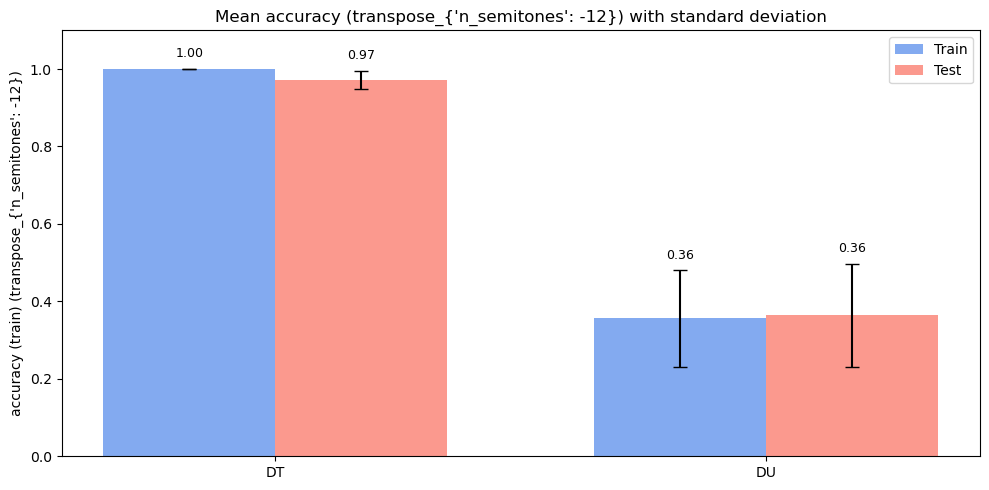

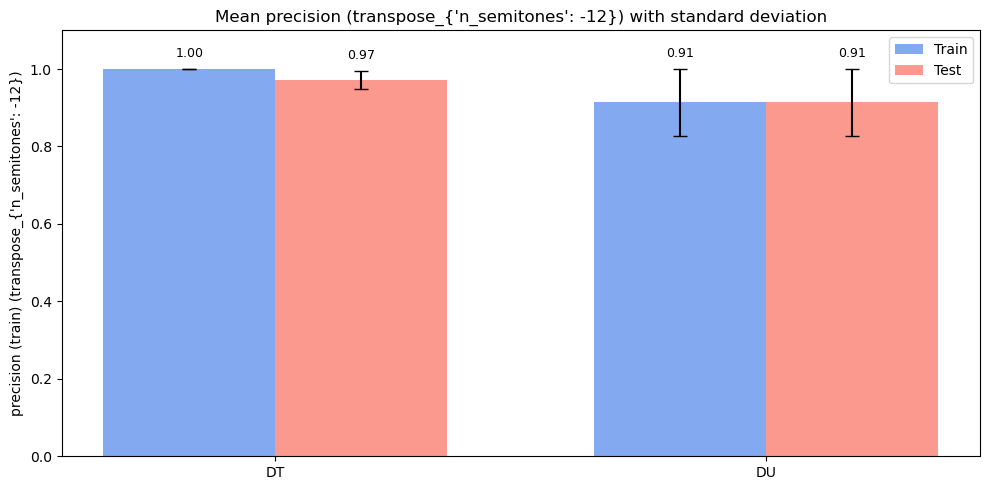

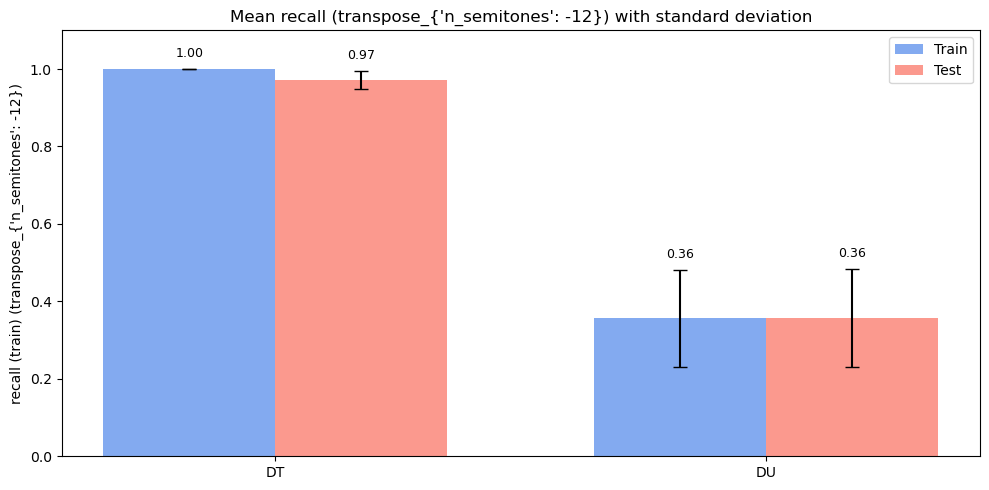

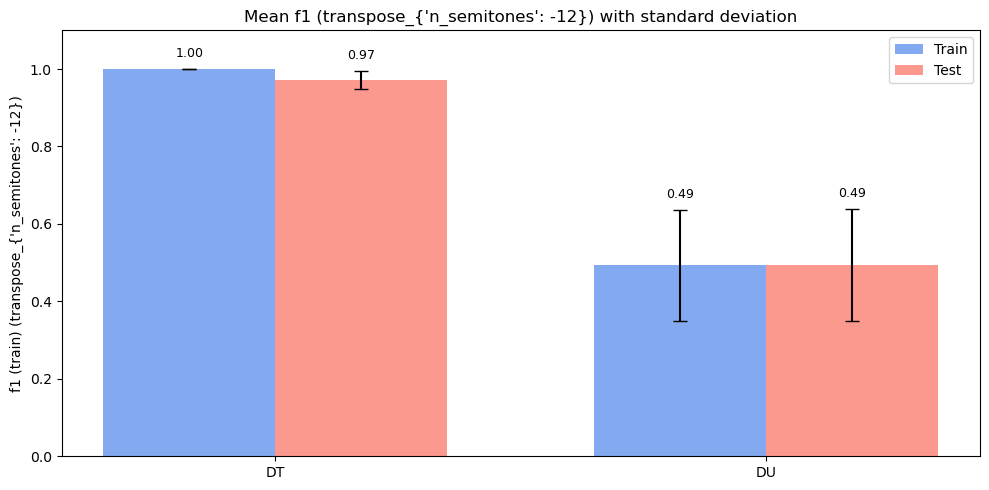

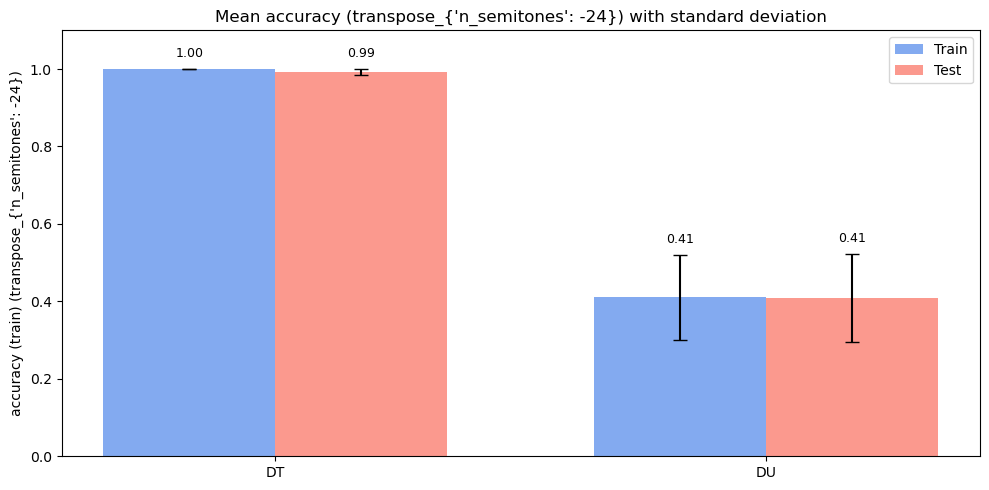

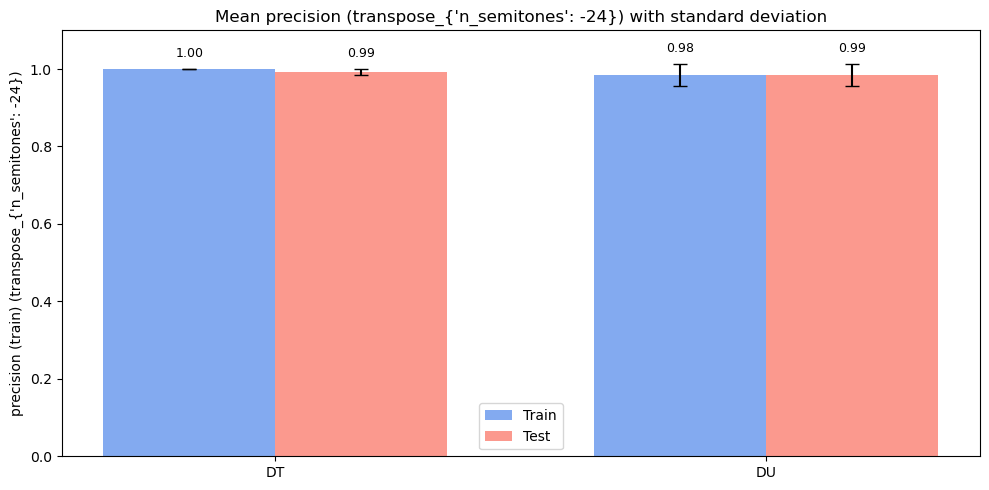

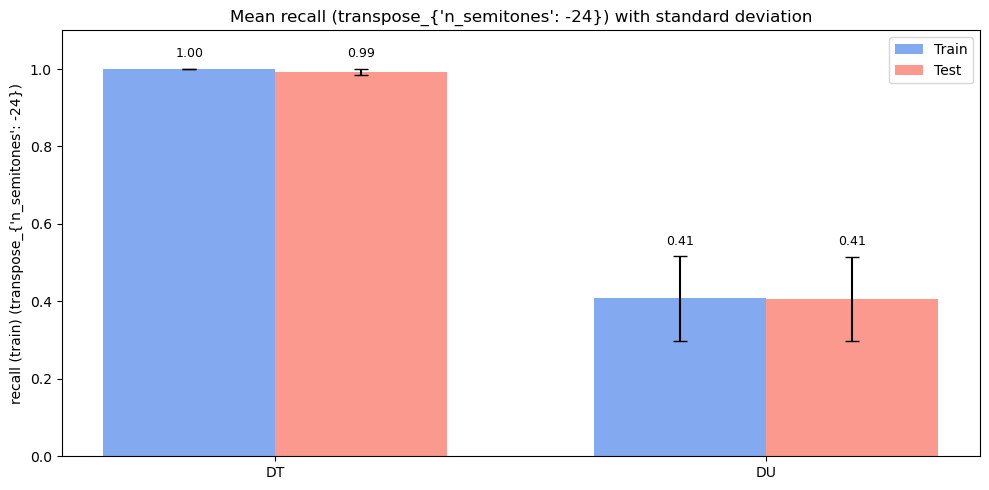

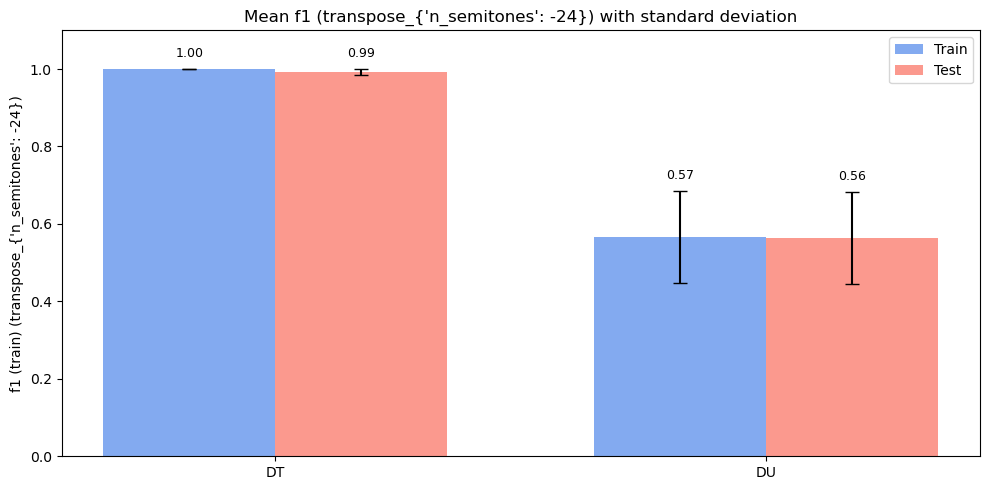

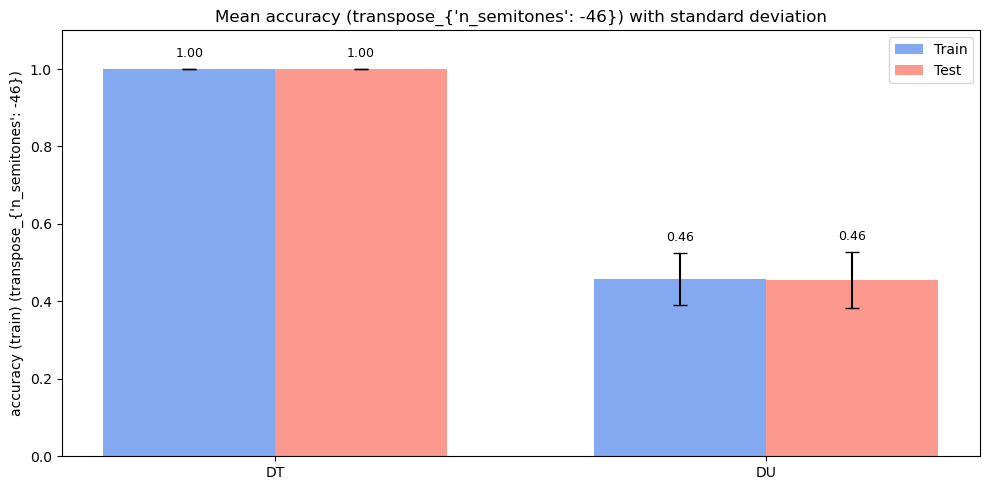

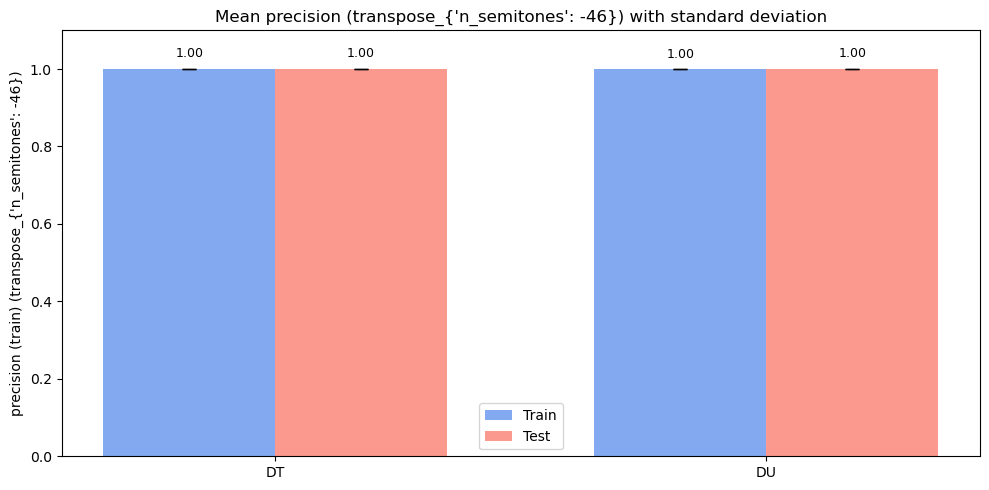

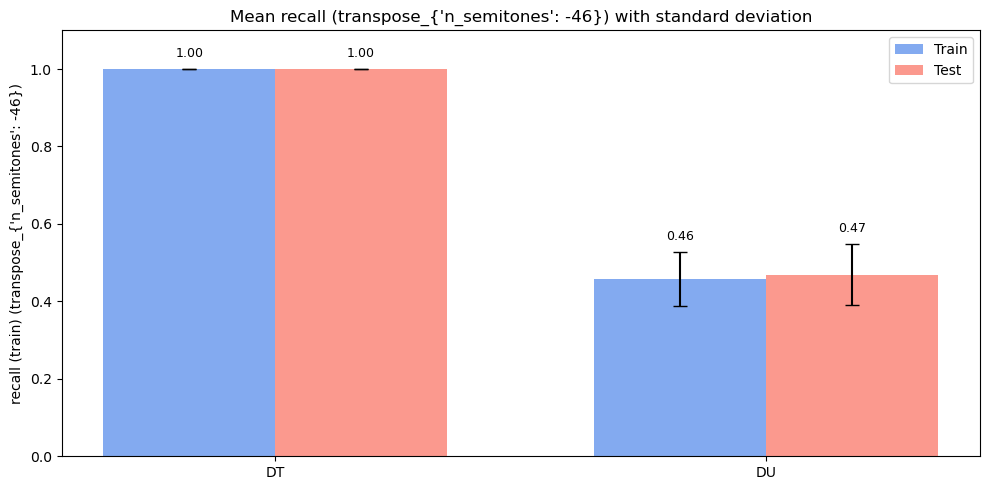

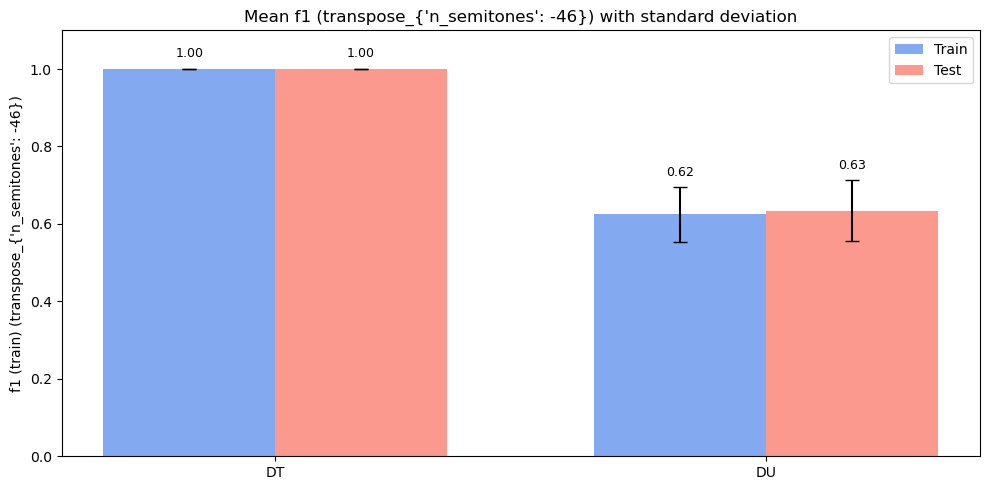

In [21]:
for mn in ml_metrics_names:
    if "train" in mn:
        mn_train = mn
        mn_test = mn.replace("train", "test")

        # Data for the two series
        train_means = metrics_mean[mn_train]
        test_means  = metrics_mean[mn_test]
        train_stds  = metrics_std[mn_train]
        test_stds   = metrics_std[mn_test]

        x = np.arange(len(model_names_short))   # positions
        width = 0.35

        plt.figure(figsize=(10, 5))

        # Two bar groups
        plt.bar(x - width/2, train_means, width,
                yerr=train_stds, capsize=5,
                label='Train', color='cornflowerblue', alpha=0.8)

        plt.bar(x + width/2, test_means, width,
                yerr=test_stds, capsize=5,
                label='Test', color='salmon', alpha=0.8)

        # Labels & layout
        plt.xticks(x, model_names_short)
        plt.ylabel(mn)
        plt.title(f'Mean {mn.replace(" (train)", "")} with standard deviation')

        if "time" not in mn:
            plt.ylim(0, 1.1)

        # Add mean value labels above bars
        for i, (mean, std) in enumerate(zip(train_means, train_stds)):
            plt.text(x[i] - width/2, mean + std + 0.03, f"{mean:.2f}",
                    ha='center', fontsize=9)

        for i, (mean, std) in enumerate(zip(test_means, test_stds)):
            plt.text(x[i] + width/2, mean + std + 0.03, f"{mean:.2f}",
                    ha='center', fontsize=9)

        plt.legend()
        plt.tight_layout()
        plt.show()

In [22]:
# Renitialize metrics collectors
s = (len(filenames),len(model_names))
ml_metrics = dict()
base_metrics_names = ["time",
                      "accuracy (train)",
                      "accuracy (test)",
                      "precision (train)",
                      "precision (test)",
                      "recall (train)",
                      "recall (test)",
                      "f1 (train)",
                      "f1 (test)",
                      ] #, "n_events", "n_classes"]
ml_metrics_names = base_metrics_names.copy()

for mn in ml_metrics_names:
    ml_metrics[mn] = np.zeros(s)

In [23]:
# Single-class, without transformations
error_collection = []
for i, filein in enumerate(filenames):    
    for u, (model_name, clf) in enumerate(zip(model_names, classifiers)):
        try: 
            metrics = amo_with_doublings_multiclass(filein,fileout=None,model=model_name, tol=0.2, transformations=None, multiclass=False, model_path=model_path)
            print(metrics)
            for mn in ml_metrics_names:
                # ml_metrics["accuracy"][i,u] = metrics["accuracy"]
                ml_metrics[mn][i,u] = metrics[mn]
        except Exception as e:
            print("Error")
            error_collection.append(f"Error with {filein} and model {model_name}: {e}")

print("\n????????? ERRORS ??????????")
for error in error_collection:
    print(error)


========= PREPROCESSING =========
[PREPROCESSING] Computing and caching results...
Mapping: [[1 'A1-Piccolo     ' 0 72]
 [1 'A1-Piccolo     ' 0 73]
 [2 'A2-Flute 2   : ' 1 73]
 [3 'A3-Oboe        ' 2 68]
 [3 'A3-Oboe        ' 2 69]
 [4 'perc' 3 42]
 [4 'perc' 3 13]
 [4 'perc' 3 40]
 [4 'perc' 3 116]
 [5 'A5-Clarinet    ' 4 71]
 [6 'A6-Clarinet    ' 5 71]
 [7 'A7-Bassoon     ' 6 70]
 [8 'A8-Bassoon     ' 7 70]
 [9 'A9-FrenchHorns ' 8 59]
 [9 'A9-FrenchHorns ' 8 60]
 [10 'A10-STANDARD 1  ' 9 48]
 [11 'A11-FrenchHorns ' 10 60]
 [11 'A11-FrenchHorns ' 10 59]
 [12 'A12-Trumpet     ' 11 56]
 [12 'A12-Trumpet     ' 11 59]
 [13 'A13-Trumpet     ' 12 56]
 [14 'A14-Trombone 2  ' 13 59]
 [14 'A14-Trombone 2  ' 13 57]
 [15 'A15-Trombone 2  ' 14 57]
 [16 'A16-Trombone 2  ' 15 57]
 [17 'B1-Tuba        ' 0 58]
 [18 'B2-Timpani     ' 1 47]
 [19 'B3-Piano 1     ' 2 0]
 [20 'B4-Piano 1     ' 2 0]
 [21 'B5-Harp        ' 4 46]
 [22 'B6-Harp        ' 4 46]
 [23 'B7-Strings   : ' 6 48]
 [23 'B7-Strings   :

In [24]:
metrics_mean = dict()
metrics_std = dict()
for mn in ml_metrics_names:
    metrics_mean[mn], metrics_std[mn] = return_m_std(ml_metrics[mn], mn)

time
[0.02532975 0.00554097]
[0.02067208 0.0032578 ]
accuracy (train)
[0.96062712 0.06390769]
[0.07470549 0.03729274]
accuracy (test)
[0.729897   0.06737173]
[0.13952602 0.05463232]
precision (train)
[0.96062712 0.06406715]
[0.07470549 0.03309722]
precision (test)
[0.73532341 0.10627438]
[0.13872461 0.06186241]
recall (train)
[0.96062712 0.06406715]
[0.07470549 0.03309722]
recall (test)
[0.729897   0.06701247]
[0.13952602 0.049847  ]
f1 (train)
[0.96062712 0.06406715]
[0.07470549 0.03309722]
f1 (test)
[0.73032783 0.07540973]
[0.13904698 0.05161669]


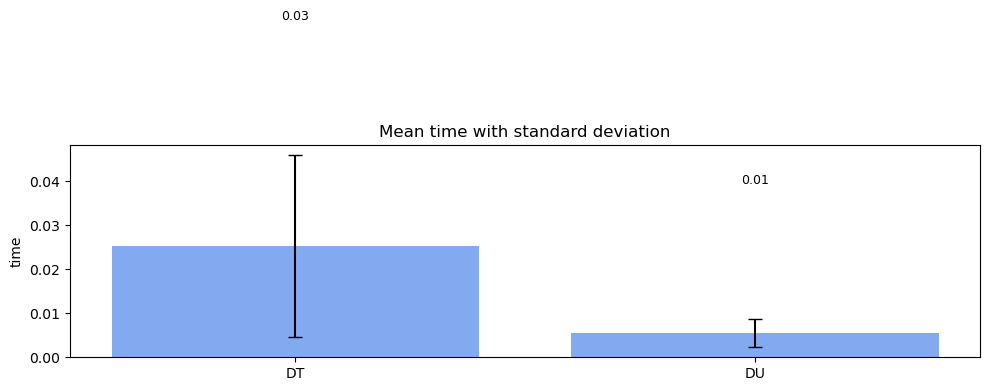

In [25]:
for mn in ml_metrics_names:
    if "time" in mn:
        # Plot
        plt.figure(figsize=(10, 5))
        barlist = plt.bar(model_names_short, metrics_mean[mn], yerr=metrics_std[mn], capsize=5, color='cornflowerblue', alpha=0.8)

        plt.ylabel(mn)
        plt.title(f'Mean {mn} with standard deviation')
        if not "time" in mn:
            plt.ylim(0, 1.1)

        # Optional: Add mean values above bars
        for i, (mean, std) in enumerate(zip(metrics_mean[mn], metrics_std[mn])):
            plt.text(i, mean + std + 0.03, f"{mean:.2f}", ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.show()

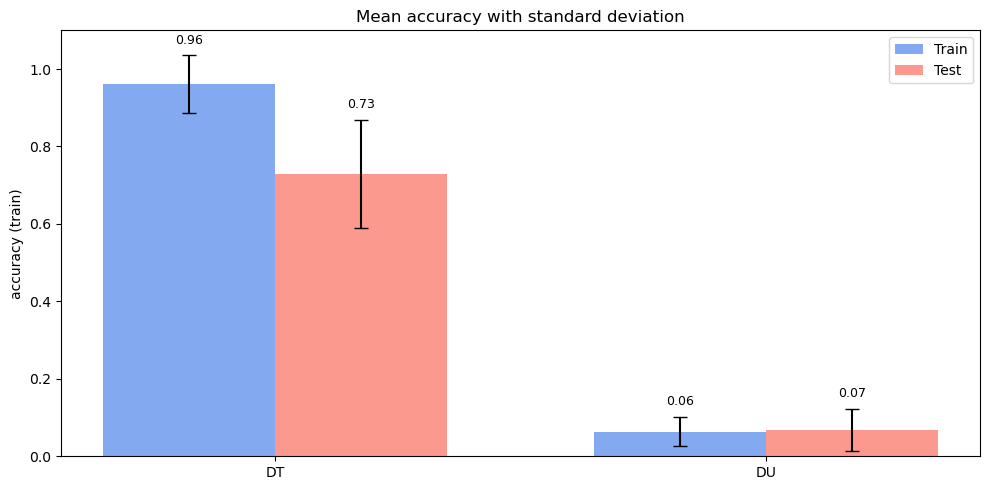

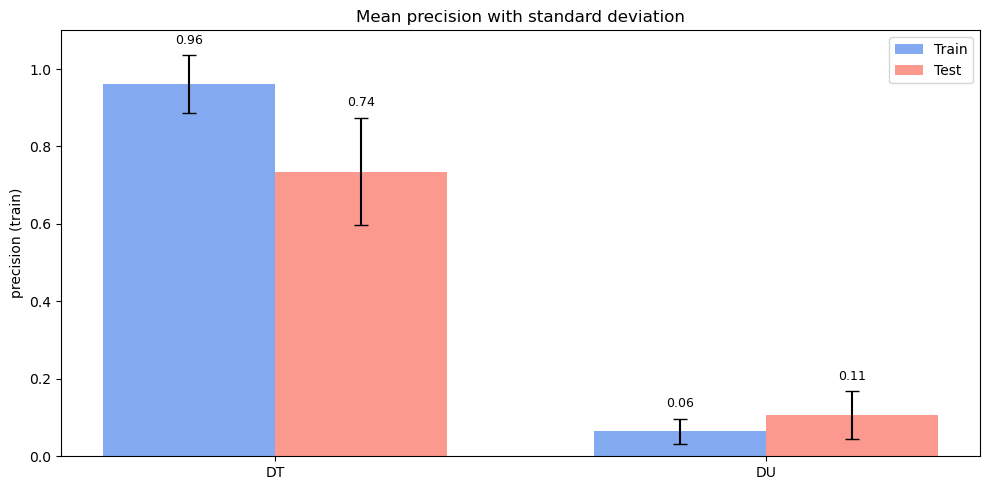

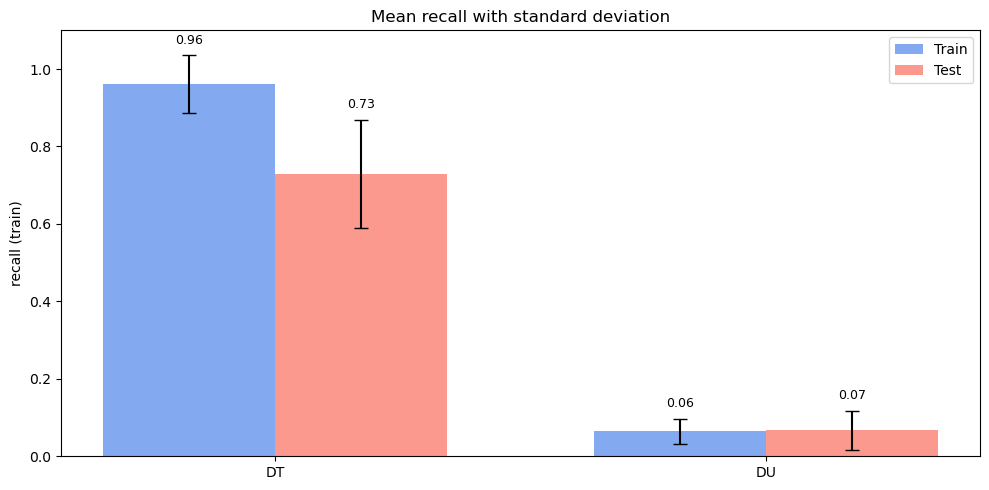

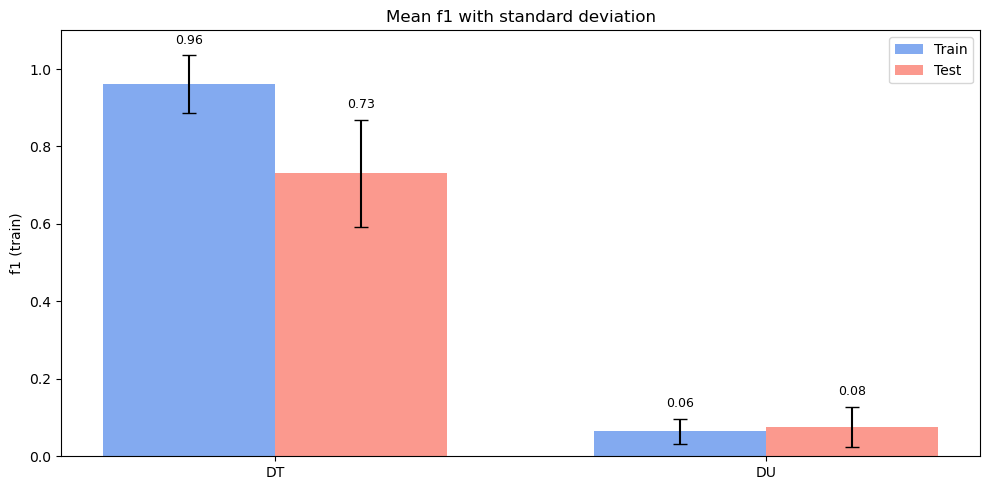

In [26]:
for mn in ml_metrics_names:
    if "train" in mn:
        mn_train = mn
        mn_test = mn.replace("train", "test")

        # Data for the two series
        train_means = metrics_mean[mn_train]
        test_means  = metrics_mean[mn_test]
        train_stds  = metrics_std[mn_train]
        test_stds   = metrics_std[mn_test]

        x = np.arange(len(model_names_short))   # positions
        width = 0.35

        plt.figure(figsize=(10, 5))

        # Two bar groups
        plt.bar(x - width/2, train_means, width,
                yerr=train_stds, capsize=5,
                label='Train', color='cornflowerblue', alpha=0.8)

        plt.bar(x + width/2, test_means, width,
                yerr=test_stds, capsize=5,
                label='Test', color='salmon', alpha=0.8)

        # Labels & layout
        plt.xticks(x, model_names_short)
        plt.ylabel(mn)
        plt.title(f'Mean {mn.replace(" (train)", "")} with standard deviation')

        if "time" not in mn:
            plt.ylim(0, 1.1)

        # Add mean value labels above bars
        for i, (mean, std) in enumerate(zip(train_means, train_stds)):
            plt.text(x[i] - width/2, mean + std + 0.03, f"{mean:.2f}",
                    ha='center', fontsize=9)

        for i, (mean, std) in enumerate(zip(test_means, test_stds)):
            plt.text(x[i] + width/2, mean + std + 0.03, f"{mean:.2f}",
                    ha='center', fontsize=9)

        plt.legend()
        plt.tight_layout()
        plt.show()